# Data Visualization

This notebook visualizes the Talent Pool dataset to identify candidate distributions, technical skills, career goals, and recruitment sources.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/retail_ecommerce_talent_pool_clean.csv")

In [3]:
skill_summary = pd.DataFrame({
    "Skill":[
        "Excel",
        "SQL",
        "Python",
        "Power BI",
        "Looker Studio",
        "Database",
        "Tableau",
        "Other Skills"
    ],
    "Total Candidates":[
        df["excel_skill"].sum(),
        df["sql_skill"].sum(),
        df["python_skill"].sum(),
        df["power_bi_skill"].sum(),
        df["looker_studio_skill"].sum(),
        df["database_skill"].sum(),
        df["tableau_skill"].sum(),
        df["other_skills"].notna().sum()
    ]
}).sort_values("Total Candidates")

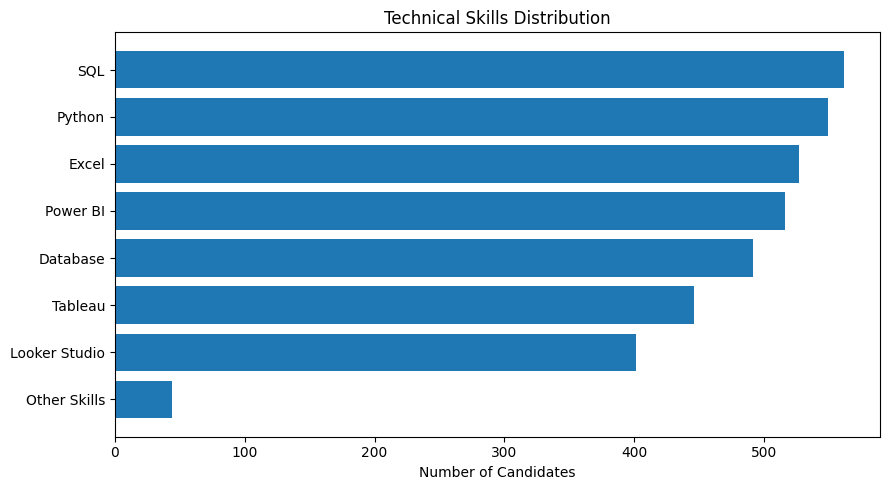

In [4]:
plt.figure(figsize=(9,5))

plt.barh(
    skill_summary["Skill"],
    skill_summary["Total Candidates"]
)

plt.title("Technical Skills Distribution")
plt.xlabel("Number of Candidates")

plt.tight_layout()
plt.show()

In [6]:
goal_summary = pd.DataFrame({
    "Goal":[
        "Looking for Job",
        "Upskilling",
        "Networking",
        "Career Switch"
    ],
    "Total Candidates":[
        df["for_job"].sum(),
        df["upskills"].sum(),
        df["networking"].sum(),
        df["switch_career"].sum()
    ]
})

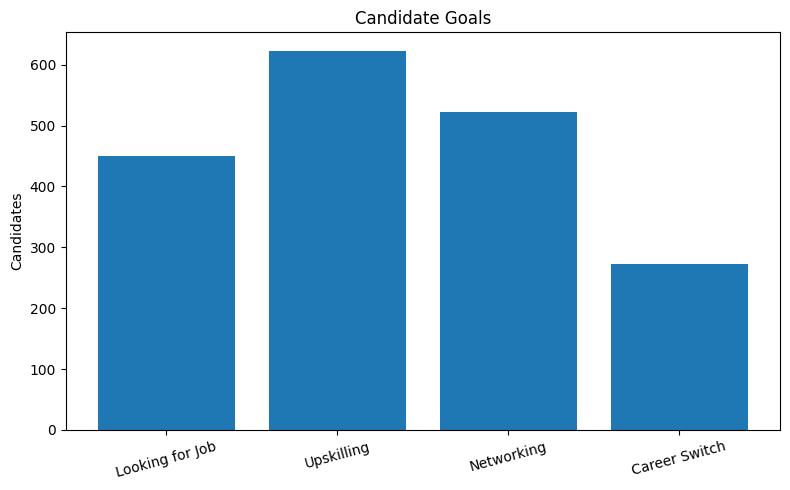

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    goal_summary["Goal"],
    goal_summary["Total Candidates"]
)

plt.title("Candidate Goals")
plt.ylabel("Candidates")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [8]:
province_summary = (
    df["province"]
      .value_counts()
      .head(10)
      .reset_index()
)

province_summary.columns = [
    "Province",
    "Total Candidates"
]

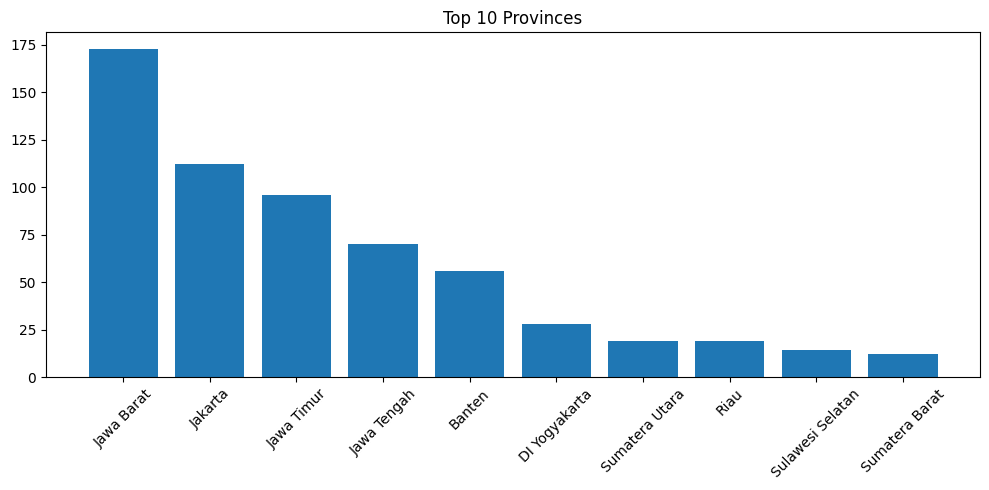

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    province_summary["Province"],
    province_summary["Total Candidates"]
)

plt.title("Top 10 Provinces")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [10]:
platform_summary = (
    df["platform_source"]
      .value_counts()
      .reset_index()
)

platform_summary.columns = [
    "Platform",
    "Total Candidates"
]

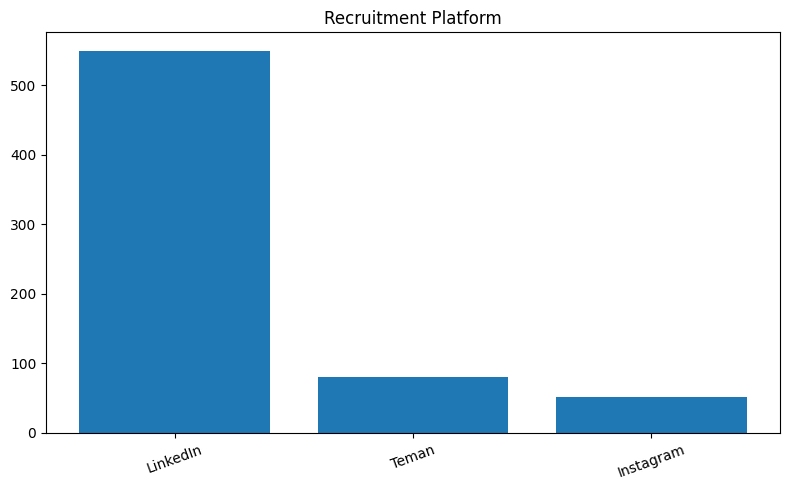

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    platform_summary["Platform"],
    platform_summary["Total Candidates"]
)

plt.title("Recruitment Platform")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [14]:
df["total_skills"] = (
    df["excel_skill"] +
    df["sql_skill"] +
    df["python_skill"] +
    df["power_bi_skill"] +
    df["looker_studio_skill"] +
    df["database_skill"] +
    df["tableau_skill"]
)

In [15]:
df["skill_level"] = pd.cut(
    df["total_skills"],
    bins=[-1,2,5,7],
    labels=[
        "Beginner",
        "Intermediate",
        "Advanced"
    ]
)

In [16]:
skill_level = (
    df["skill_level"]
      .value_counts()
      .reset_index()
)

skill_level.columns = [
    "Skill Level",
    "Total Candidates"
]

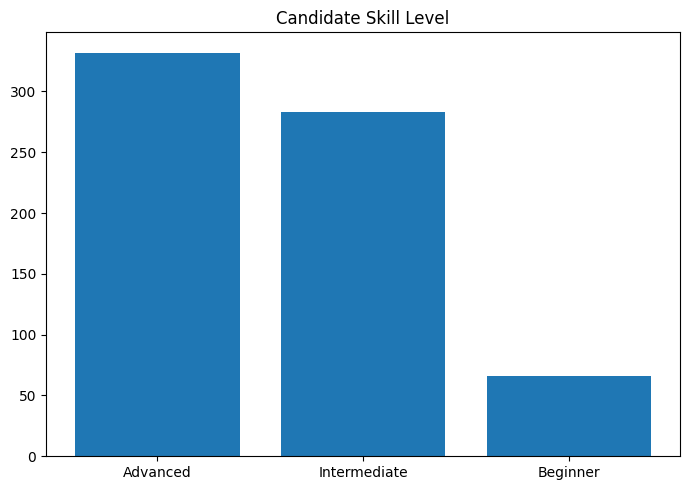

In [17]:
plt.figure(figsize=(7,5))

plt.bar(
    skill_level["Skill Level"],
    skill_level["Total Candidates"]
)

plt.title("Candidate Skill Level")

plt.tight_layout()

plt.show()

### Technical Skills Distribution

Insight:

- Excel is the most common technical skill among candidates.
- SQL and Python are the second and third most common skills.
- Tableau is the least common technical skill.